# CS3244 Group 17 Project: IMDb Spoiler Detection from Movie Reviews

This notebook focuses on the model-training stage for binary spoiler classification on IMDb reviews, loading preprocessed splits and precomputed features (TF-IDF, TF-IDF+lemma, Sentence-BERT) to tune, train, and evaluate classifiers.

Workflow: setup and data loading, data cleaning and preprocessing, data splitting, model training and model evaluation.

## 1. Setup and Data Loading

In [1]:
# imports
import pandas as pd
import numpy as np
import joblib, re, html, unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from pathlib import Path
from scipy import sparse
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm

/Users/adamloh/miniconda3/envs/cs3244/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Read review dataset
df = pd.read_json("IMDB_reviews.json", lines=True)

## 2. Data Cleaning and Preprocessing
This section performs cleaning and preprocessing to build the master dataset used across all downstream modeling steps.

In [3]:
# create master dataset
df_master = df.copy()

In [4]:
# Remove duplicate reviews which have different label assigned to the same text
conflicts = df_master.groupby("review_text")["is_spoiler"].nunique()
conflicts = conflicts[conflicts > 1].index

df_master = df_master[~df_master["review_text"].isin(conflicts)]

# Remove exact duplicate reviews to avoid redundancy and data leakage
df_master = df_master.drop_duplicates(subset=["review_text"])

# Remove extremely short reviews that are likely low-information or noisy
df_master = df_master[df_master["review_text"].str.len() > 25]

# Remove extremely long reviews that may distort feature distributions and increase computational cost
df_master = df_master[df_master["review_text"].str.len() < 10000]

# Add review length as a feature due to strong correlation with spoiler labels
df_master["length"] = df_master["review_text"].str.len()

# Reset index after row removals to keep the cleaned dataset tidy and consistent
df_master = df_master.reset_index(drop=True)

In [5]:
# Review date stored as object, convert to datetime
df_master["review_date"] = pd.to_datetime(df_master["review_date"])

In [6]:
# Basic data cleaning function
def basic_clean(text):
    text = str(text) # Forces text to be a String
    text = html.unescape(text) # Converts HTML to normal text
    text = unicodedata.normalize("NFKC", text) # Normalizes unicode into a consistent canonical form
    text = re.sub(r"<[^>]+>", " ", text) # Removes HTML tags 
    text = text.lower() # Converts all text to lowercase
    text = re.sub(r"\s+", " ", text) # Collapses all whitespace into a single space
    text = text.strip() # Removes whitespace in front and behind of text
    return text

In [7]:
# Clean "clean_text" in master dataframe
df_master["clean_text"] = df_master["review_text"].apply(basic_clean)

## 3. Data Splitting
Split data by movies so that the model doesnt try to learn movie specific context to detect spoilers.  
Train/test split is group-based (by `movie_id`) and **CV is Stratified Group K-Fold** on the training portion.  
Approximate Split Proportion:  
Training: 0.80  
Testing: 0.20

In [8]:
# Function for splitting data into training and testing sets
def group_data_split(df, group_col="movie_id", test_size=0.2, random_state=42):
    """
    Split a dataframe into train and test sets using group-based splitting.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    group_col : str, default="movie_id"
        Column used to define groups that must not be split across train and test.
    test_size : float, default=0.2
        Proportion of groups to place in the test set.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    df_train : pandas.DataFrame
        Training subset.
    df_test : pandas.DataFrame
        Test subset.
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    return df_train, df_test

In [9]:
# Splitting data into training set and testing set (grouped by movie_id)
df_train, df_test = group_data_split(
    df_master, 
    group_col="movie_id", 
    test_size=0.2, 
    random_state=42
)

In [10]:
# Create Stratified Group K-Fold splits on the training set
N_SPLITS = 5
CV_SEED = 42
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

cv_splits = list(
    cv.split(
        df_train["clean_text"],
        df_train["is_spoiler"],
        groups=df_train["movie_id"],
    )
)
print("Number of CV folds:", len(cv_splits))

Number of CV folds: 5


## 4. Model Training and Hyperparameter Tuning

This section uses a fixed model-selection protocol to keep comparisons fair and avoid leakage.

- `df_train` is used for cross-validation and final model fitting.
- `cv_splits` contains the fixed folds reused across feature engineering methods.
- `df_test` is reserved for one-time final evaluation only.

For each model family, the workflow is:
1. Run cross-validation on `df_train` to select hyperparameters.
2. Refit the model on the full training set.
3. Evaluate once on `df_test` in Section 6.

### 4.1 Shared Tuning Settings

All models in Section 5 select hyperparameters by mean validation AUC using the same cross-validation protocol. The search ranges are defined once below for consistency, while feature-specific implementation details such as sparse versus dense preprocessing remain inside the individual model cells.

This subsection contains the shared scoring, fold-count, random seed, and search ranges used during model selection. The fast-rerun fixed hyperparameters are separated into the next subsection.

In [11]:
SCORING_METRIC = "roc_auc"
N_SPLITS = 5
RANDOM_STATE = 42
CLASS_WEIGHT = "balanced"

LR_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
BERT_LR_C_GRID = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
LR_MAX_ITER = 2000

SVM_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
SVM_TOL = 1e-4
SVM_MAX_ITER = 3000
SVM_CALIBRATION_CV = 3
SVM_CALIBRATION_METHOD = "sigmoid"

DT_PARAM_GRID = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [10, 25, 50],
    "min_samples_leaf": [5, 10, 20],
    "ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],
}
DT_RANDOM_SEARCH_ITER = 10

### 4.2 Fast Rerun Settings

This subsection stores fixed hyperparameters from earlier CV results so repeated runs can skip tuning and go straight to refitting on the full training split.

Set `USE_FIXED_BEST_PARAMS = True` to use the saved values below when they are available. Leave a value as `None` if that model has not completed its first tuning run yet.

In [23]:
USE_FIXED_BEST_PARAMS = True

LR_TFIDF_FIXED_C = 0.3
LR_TFIDF_LEMMA_FIXED_C = 0.3
LR_BERT_FIXED_C = 10.0
SVM_TFIDF_FIXED_C = 0.03
SVM_TFIDF_LEMMA_FIXED_C = 0.03
SVM_BERT_FIXED_C = 3.0
DT_TFIDF_FIXED_PARAMS = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
DT_TFIDF_LEMMA_FIXED_PARAMS = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
DT_BERT_FIXED_PARAMS = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
RF_TF_IDF_FIXED_PARAMS = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}
RF_TF_IDF_LEMMA_FIXED_PARAMS = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}

### 4.3 Feature Artifact Loading

Run the next cell to define helper functions for loading the saved train, validation, and test artifacts from disk; later sections will call these loaders to reuse the exact same prepared inputs.

In [13]:
# Load CV artifacts into memory for downstream model training
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def load_cv_fold(fold_idx):
    fold_tag = f"fold{fold_idx}"
    artifacts = {}
    artifacts["y_train"] = np.load(ARTIFACT_DIR / f"labels_train_{fold_tag}.npy")
    artifacts["y_val"] = np.load(ARTIFACT_DIR / f"labels_val_{fold_tag}.npy")
    artifacts["X_tfidf_train"] = sparse.load_npz(ARTIFACT_DIR / f"X_tfidf_train_{fold_tag}.npz")
    artifacts["X_tfidf_val"] = sparse.load_npz(ARTIFACT_DIR / f"X_tfidf_val_{fold_tag}.npz")
    # artifacts["tfidf_vectorizer"] = joblib.load(ARTIFACT_DIR / f"tfidf_vectorizer_{fold_tag}.joblib")
    artifacts["X_tfidf_lemma_train"] = sparse.load_npz(ARTIFACT_DIR / f"X_tfidf_lemma_train_{fold_tag}.npz")
    artifacts["X_tfidf_lemma_val"] = sparse.load_npz(ARTIFACT_DIR / f"X_tfidf_lemma_val_{fold_tag}.npz")
    # artifacts["tfidf_lemma_vectorizer"] = joblib.load(ARTIFACT_DIR / f"tfidf_lemma_vectorizer_{fold_tag}.joblib")
    return artifacts

def load_full_train_test():
    artifacts = {}
    artifacts["y_train_full"] = np.load(ARTIFACT_DIR / "labels_train_full.npy")
    artifacts["y_test"] = np.load(ARTIFACT_DIR / "labels_test.npy")
    artifacts["X_tfidf_train_full"] = sparse.load_npz(ARTIFACT_DIR / "X_tfidf_train_full.npz")
    artifacts["X_tfidf_test"] = sparse.load_npz(ARTIFACT_DIR / "X_tfidf_test.npz")
    # artifacts["tfidf_vectorizer_full"] = joblib.load(ARTIFACT_DIR / "tfidf_vectorizer_full.joblib")
    artifacts["X_tfidf_lemma_train_full"] = sparse.load_npz(ARTIFACT_DIR / "X_tfidf_lemma_train_full.npz")
    artifacts["X_tfidf_lemma_test"] = sparse.load_npz(ARTIFACT_DIR / "X_tfidf_lemma_test.npz")
    # artifacts["tfidf_lemma_vectorizer_full"] = joblib.load(ARTIFACT_DIR / "tfidf_lemma_vectorizer_full.joblib")
    artifacts["X_bert_train_full"] = np.load(ARTIFACT_DIR / "X_bert_train_full.npy")
    artifacts["X_bert_test"] = np.load(ARTIFACT_DIR / "X_bert_test.npy")
    return artifacts

### 4.4 Logistic Regression

#### 4.4.1 TF-IDF

In [10]:
from sklearn.linear_model import LogisticRegression

if USE_FIXED_BEST_PARAMS and LR_TFIDF_FIXED_C is not None:
    best_c = LR_TFIDF_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"LR TF-IDF fixed C={best_c:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]

        model = LogisticRegression(
            C=best_c,
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details = pd.DataFrame(fold_rows)
    fixed_cv_summary = fixed_cv_fold_details[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows = []
    cv_fold_details_by_c = {}

    for c_value in tqdm(LR_C_GRID, desc="LR TF-IDF C search"):
        fold_rows = []

        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_train"]
            X_val = artifacts["X_tfidf_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]

            model = LogisticRegression(
                C=c_value,
                solver="saga",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)

            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c[c_value] = fold_df

        cv_summary_rows.append(
            {
                "C": c_value,
                "mean_auc": fold_df["auc"].mean(),
                "std_auc": fold_df["auc"].std(),
                "mean_average_precision": fold_df["average_precision"].mean(),
                "mean_f1": fold_df["f1"].mean(),
                "mean_f2": fold_df["f2"].mean(),
                "mean_precision": fold_df["precision"].mean(),
                "mean_recall": fold_df["recall"].mean(),
                "mean_accuracy": fold_df["accuracy"].mean(),
            }
        )

    cv_results = pd.DataFrame(cv_summary_rows).sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_c = float(cv_results.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c[best_c].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary = cv_fold_details_by_c[best_c][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]

final_model = LogisticRegression(
    C=best_c,
    solver="saga",
    max_iter=LR_MAX_ITER,
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
)
final_model.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
logreg_tfidf_best_c = best_c
logreg_tfidf_model = final_model

LR TF-IDF fixed C=0.3: 100%|██████████| 5/5 [00:51<00:00, 10.25s/it]

Using fixed C: 0.3 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.765549,0.566528,0.549678,0.601913,0.480221,0.642625,0.721545,1
1,0.768592,0.569996,0.551341,0.598124,0.487758,0.633988,0.726853,2
2,0.763108,0.563190,0.546560,0.598210,0.477803,0.638431,0.719698,3
3,0.763955,0.557244,0.545006,0.600208,0.472569,0.643672,0.716677,4
4,0.763460,0.565137,0.546105,0.593354,0.482121,0.629672,0.724490,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.764933,0.564419,0.547738,0.598362,0.480094,0.637678,0.721853


#### 4.4.2 TF-IDF + Lemmatization

In [11]:
from sklearn.linear_model import LogisticRegression

if USE_FIXED_BEST_PARAMS and LR_TFIDF_LEMMA_FIXED_C is not None:
    best_c_lemma = LR_TFIDF_LEMMA_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"LR TF-IDF+Lemma fixed C={best_c_lemma:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]

        model = LogisticRegression(
            C=best_c_lemma,
            solver="saga",
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)

        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_lemma = pd.DataFrame(fold_rows)
    fixed_cv_summary_lemma = fixed_cv_fold_details_lemma[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_lemma} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_lemma.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_lemma.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_lemma = []
    cv_fold_details_by_c_lemma = {}

    for c_value in tqdm(LR_C_GRID, desc="LR TF-IDF+Lemma C search"):
        fold_rows = []

        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_lemma_train"]
            X_val = artifacts["X_tfidf_lemma_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]

            model = LogisticRegression(
                C=c_value,
                solver="saga",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)

            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_lemma[c_value] = fold_df

        cv_summary_rows_lemma.append(
            {
                "C": c_value,
                "mean_auc": fold_df["auc"].mean(),
                "std_auc": fold_df["auc"].std(),
                "mean_average_precision": fold_df["average_precision"].mean(),
                "mean_f1": fold_df["f1"].mean(),
                "mean_f2": fold_df["f2"].mean(),
                "mean_precision": fold_df["precision"].mean(),
                "mean_recall": fold_df["recall"].mean(),
                "mean_accuracy": fold_df["accuracy"].mean(),
            }
        )

    cv_results_lemma = pd.DataFrame(cv_summary_rows_lemma).sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_lemma.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_c_lemma = float(cv_results_lemma.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_lemma}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_lemma[best_c_lemma].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_lemma = cv_fold_details_by_c_lemma[best_c_lemma][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_lemma.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_lemma_train_full"]
y_train_full = artifacts["y_train_full"]

final_model_lemma = LogisticRegression(
    C=best_c_lemma,
    solver="saga",
    max_iter=LR_MAX_ITER,
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
)
final_model_lemma.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
logreg_tfidf_lemma_best_c = best_c_lemma
logreg_tfidf_lemma_model = final_model_lemma

LR TF-IDF+Lemma fixed C=0.3: 100%|██████████| 5/5 [00:50<00:00, 10.06s/it]

Using fixed C: 0.3 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.764332,0.565188,0.548024,0.600670,0.478174,0.641771,0.720050,1
1,0.768075,0.569749,0.550871,0.597512,0.487454,0.633256,0.726649,2
2,0.762640,0.563262,0.545917,0.597495,0.477253,0.637658,0.719310,3
3,0.764020,0.558171,0.545142,0.599995,0.473060,0.643138,0.717066,4
4,0.762963,0.565322,0.544794,0.593540,0.479200,0.631192,0.722360,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.764406,0.564338,0.546949,0.597842,0.479028,0.637403,0.721087


#### 4.4.3 BERT Embeddings

In [26]:
from sklearn.linear_model import LogisticRegression

artifacts = load_full_train_test()
X_bert_train_full = artifacts["X_bert_train_full"]
y_train_full = artifacts["y_train_full"]

if USE_FIXED_BEST_PARAMS and LR_BERT_FIXED_C is not None:
    best_c_bert = LR_BERT_FIXED_C
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in tqdm(
        enumerate(cv_splits, 1),
        total=len(cv_splits),
        desc=f"LR BERT fixed C={best_c_bert:g}",
    ):
        X_train = X_bert_train_full[train_idx]
        X_val = X_bert_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_val = y_train_full[val_idx]
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=best_c_bert,
                solver="lbfgs",
                max_iter=LR_MAX_ITER,
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            ),
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_bert = pd.DataFrame(fold_rows)
    fixed_cv_summary_bert = fixed_cv_fold_details_bert[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_bert} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_bert.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_bert.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_bert = []
    cv_fold_details_by_c_bert = {}

    for c_value in tqdm(BERT_LR_C_GRID, desc="LR BERT C search"):
        fold_rows = []
        for fold_idx, (train_idx, val_idx) in tqdm(
            enumerate(cv_splits, 1),
            total=len(cv_splits),
            desc=f"CV folds (C={c_value:g})",
            leave=False,
        ):
            X_train = X_bert_train_full[train_idx]
            X_val = X_bert_train_full[val_idx]
            y_train = y_train_full[train_idx]
            y_val = y_train_full[val_idx]
            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=c_value,
                    solver="lbfgs",
                    max_iter=LR_MAX_ITER,
                    random_state=RANDOM_STATE,
                    class_weight=CLASS_WEIGHT,
                ),
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_bert[c_value] = fold_df
        cv_summary_rows_bert.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_bert = pd.DataFrame(cv_summary_rows_bert).sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_bert.rename(columns={"mean_average_precision": "mean_pr-auc"}))

    best_c_bert = float(cv_results_bert.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_bert}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_bert[best_c_bert].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_bert = cv_fold_details_by_c_bert[best_c_bert][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_bert.rename(columns={"average_precision": "pr-auc"}))

final_model_bert = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_c_bert,
        solver="lbfgs",
        max_iter=LR_MAX_ITER,
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    ),
)
final_model_bert.fit(X_bert_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
logreg_bert_best_c = best_c_bert
logreg_bert_model = final_model_bert

LR BERT fixed C=10: 100%|██████████| 5/5 [00:40<00:00,  8.19s/it]

Using fixed C: 10.0 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.726895,0.487880,0.508604,0.594221,0.410119,0.669336,0.657958,1
1,0.732123,0.493734,0.515602,0.599903,0.417760,0.673292,0.665103,2
2,0.724164,0.481267,0.508867,0.593639,0.411038,0.667806,0.658905,3
3,0.720639,0.474468,0.503040,0.586004,0.407003,0.658396,0.657058,4
4,0.722283,0.482557,0.504410,0.582487,0.412302,0.649511,0.664054,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.725221,0.483981,0.508104,0.591251,0.411644,0.663668,0.660615


### 4.5 Support Vector Machine

#### 4.5.1 TF-IDF

In [27]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

if USE_FIXED_BEST_PARAMS and SVM_TFIDF_FIXED_C is not None:
    best_c_svm = SVM_TFIDF_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"SVM TF-IDF fixed C={best_c_svm:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        svm = LinearSVC(C=best_c_svm, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
        model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_svm = pd.DataFrame(fold_rows)
    fixed_cv_summary_svm = fixed_cv_fold_details_svm[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_svm} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_svm.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_svm.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_svm = []
    cv_fold_details_by_c_svm = {}

    for c_value in tqdm(SVM_C_GRID, desc="SVM TF-IDF C search"):
        fold_rows = []
        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_train"]
            X_val = artifacts["X_tfidf_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            svm = LinearSVC(C=c_value, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
            model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_svm[c_value] = fold_df
        cv_summary_rows_svm.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_svm = pd.DataFrame(cv_summary_rows_svm).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_svm.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_c_svm = float(cv_results_svm.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_svm}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_svm[best_c_svm].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_svm = cv_fold_details_by_c_svm[best_c_svm][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_svm.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]
final_svm = LinearSVC(C=best_c_svm, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
final_model_svm = CalibratedClassifierCV(final_svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
final_model_svm.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
svm_tfidf_best_c = best_c_svm
svm_tfidf_model = final_model_svm

SVM TF-IDF fixed C=0.03: 100%|██████████| 5/5 [01:01<00:00, 12.28s/it]

Using fixed C: 0.03 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.765253,0.563880,0.393348,0.314514,0.675577,0.277443,0.773681,1
1,0.768599,0.567243,0.387659,0.307630,0.684395,0.270414,0.773852,2
2,0.763525,0.561237,0.374697,0.294320,0.687711,0.257496,0.772589,3
3,0.764388,0.555691,0.387006,0.308633,0.670985,0.271922,0.772911,4
4,0.763310,0.562523,0.390698,0.311153,0.680751,0.273967,0.775077,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.765015,0.562115,0.386682,0.30725,0.679884,0.270249,0.773622


#### 4.5.2 TF-IDF + Lemmatization

In [28]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

if USE_FIXED_BEST_PARAMS and SVM_TFIDF_LEMMA_FIXED_C is not None:
    best_c_svm_lemma = SVM_TFIDF_LEMMA_FIXED_C
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"SVM TF-IDF+Lemma fixed C={best_c_svm_lemma:g}"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        svm = LinearSVC(C=best_c_svm_lemma, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
        model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_svm_lemma = pd.DataFrame(fold_rows)
    fixed_cv_summary_svm_lemma = fixed_cv_fold_details_svm_lemma[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_svm_lemma} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_svm_lemma.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_svm_lemma.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_svm_lemma = []
    cv_fold_details_by_c_svm_lemma = {}

    for c_value in tqdm(SVM_C_GRID, desc="SVM TF-IDF+Lemma C search"):
        fold_rows = []
        for fold_idx in tqdm(range(1, N_SPLITS + 1), desc=f"CV folds (C={c_value:g})", leave=False):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_lemma_train"]
            X_val = artifacts["X_tfidf_lemma_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            svm = LinearSVC(C=c_value, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
            model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_svm_lemma[c_value] = fold_df
        cv_summary_rows_svm_lemma.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_svm_lemma = pd.DataFrame(cv_summary_rows_svm_lemma).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_svm_lemma.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_c_svm_lemma = float(cv_results_svm_lemma.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_svm_lemma}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_svm_lemma[best_c_svm_lemma].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_svm_lemma = cv_fold_details_by_c_svm_lemma[best_c_svm_lemma][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_svm_lemma.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_lemma_train_full"]
y_train_full = artifacts["y_train_full"]
final_svm_lemma = LinearSVC(C=best_c_svm_lemma, tol=SVM_TOL, max_iter=SVM_MAX_ITER, dual="auto", random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
final_model_svm_lemma = CalibratedClassifierCV(final_svm_lemma, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
final_model_svm_lemma.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
svm_tfidf_lemma_best_c = best_c_svm_lemma
svm_tfidf_lemma_model = final_model_svm_lemma

SVM TF-IDF+Lemma fixed C=0.03: 100%|██████████| 5/5 [01:04<00:00, 12.92s/it]

Using fixed C: 0.03 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.764170,0.562749,0.397306,0.317939,0.680371,0.280574,0.774885,1
1,0.767991,0.567134,0.389232,0.308879,0.687172,0.271512,0.774433,2
2,0.763006,0.561245,0.375522,0.294843,0.690372,0.257903,0.773030,3
3,0.764368,0.556536,0.388782,0.310068,0.673917,0.273193,0.773549,4
4,0.762715,0.562735,0.391247,0.311833,0.679780,0.274665,0.775023,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.76445,0.56208,0.388418,0.308712,0.682323,0.271569,0.774184


#### 4.5.3 BERT Embeddings

In [29]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

artifacts = load_full_train_test()
X_bert_train_full = artifacts["X_bert_train_full"]
y_train_full = artifacts["y_train_full"]

if USE_FIXED_BEST_PARAMS and SVM_BERT_FIXED_C is not None:
    best_c_svm_bert = SVM_BERT_FIXED_C
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in tqdm(
        enumerate(cv_splits, 1),
        total=len(cv_splits),
        desc=f"SVM BERT fixed C={best_c_svm_bert:g}",
    ):
        X_train = X_bert_train_full[train_idx]
        X_val = X_bert_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_val = y_train_full[val_idx]
        svm = make_pipeline(
            StandardScaler(),
            LinearSVC(
                C=best_c_svm_bert,
                tol=SVM_TOL,
                max_iter=SVM_MAX_ITER,
                dual="auto",
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            ),
        )
        model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_svm_bert = pd.DataFrame(fold_rows)
    fixed_cv_summary_svm_bert = fixed_cv_fold_details_svm_bert[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed C: {best_c_svm_bert} (full search skipped)")
    print("Fold-by-fold metrics for fixed C:")
    display(fixed_cv_fold_details_svm_bert.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed C:")
    display(fixed_cv_summary_svm_bert.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_svm_bert = []
    cv_fold_details_by_c_svm_bert = {}

    for c_value in tqdm(SVM_C_GRID, desc="SVM BERT C search"):
        fold_rows = []
        for fold_idx, (train_idx, val_idx) in tqdm(
            enumerate(cv_splits, 1),
            total=len(cv_splits),
            desc=f"CV folds (C={c_value:g})",
            leave=False,
        ):
            X_train = X_bert_train_full[train_idx]
            X_val = X_bert_train_full[val_idx]
            y_train = y_train_full[train_idx]
            y_val = y_train_full[val_idx]
            svm = make_pipeline(
                StandardScaler(),
                LinearSVC(
                    C=c_value,
                    tol=SVM_TOL,
                    max_iter=SVM_MAX_ITER,
                    dual="auto",
                    random_state=RANDOM_STATE,
                    class_weight=CLASS_WEIGHT,
                ),
            )
            model = CalibratedClassifierCV(svm, cv=SVM_CALIBRATION_CV, method=SVM_CALIBRATION_METHOD)
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)

        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_c_svm_bert[c_value] = fold_df
        cv_summary_rows_svm_bert.append({
            "C": c_value,
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_svm_bert = pd.DataFrame(cv_summary_rows_svm_bert).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across C values (ranked by mean AUC):")
    display(cv_results_svm_bert.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_c_svm_bert = float(cv_results_svm_bert.loc[0, "C"])
    print(f"\nBest C by CV mean AUC: {best_c_svm_bert}")
    print("Fold-by-fold metrics for best C:")
    display(cv_fold_details_by_c_svm_bert[best_c_svm_bert].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_svm_bert = cv_fold_details_by_c_svm_bert[best_c_svm_bert][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best C:")
    display(best_cv_summary_svm_bert.rename(columns={"average_precision": "pr-auc"}))

final_svm_bert = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=best_c_svm_bert,
        tol=SVM_TOL,
        max_iter=SVM_MAX_ITER,
        dual="auto",
        random_state=RANDOM_STATE,
        class_weight=CLASS_WEIGHT,
    ),
)
final_model_svm_bert = CalibratedClassifierCV(
    final_svm_bert,
    cv=SVM_CALIBRATION_CV,
    method=SVM_CALIBRATION_METHOD,
)
final_model_svm_bert.fit(X_bert_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
svm_bert_best_c = best_c_svm_bert
svm_bert_model = final_model_svm_bert

SVM BERT fixed C=3: 100%|██████████| 5/5 [07:43<00:00, 92.67s/it]

Using fixed C: 3.0 (full search skipped)
Fold-by-fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.727232,0.487843,0.291505,0.222445,0.604065,0.192104,0.753048,1
1,0.732540,0.494147,0.293002,0.222617,0.619391,0.191887,0.754861,2
2,0.724600,0.481243,0.281615,0.213995,0.594935,0.184466,0.750972,3
3,0.720857,0.474385,0.280732,0.213604,0.589501,0.184234,0.751124,4
4,0.722331,0.482638,0.276883,0.208182,0.615308,0.178633,0.754406,5


Average fold metrics for fixed C:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.725512,0.484051,0.284747,0.216169,0.60464,0.186265,0.752882


### 4.6 Decision Tree

#### 4.6.1 TF-IDF

In [14]:
DT_INT_PARAMS = ["max_depth", "min_samples_split", "min_samples_leaf"]
DT_FLOAT_PARAMS = ["ccp_alpha"]

def normalize_dt_params(params_like):
    params = dict(params_like)
    for name in DT_INT_PARAMS:
        value = params.get(name)
        params[name] = None if value is None or pd.isna(value) else int(value)
    for name in DT_FLOAT_PARAMS:
        value = params.get(name)
        params[name] = float(value)
    return params

##### Baseline Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

if USE_FIXED_BEST_PARAMS and DT_TFIDF_FIXED_PARAMS is not None:
    best_params_dt = normalize_dt_params(DT_TFIDF_FIXED_PARAMS)
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="DT TF-IDF fixed params"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        model = DecisionTreeClassifier(
            max_depth=best_params_dt["max_depth"],
            min_samples_split=best_params_dt["min_samples_split"],
            min_samples_leaf=best_params_dt["min_samples_leaf"],
            ccp_alpha=best_params_dt["ccp_alpha"],
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_dt = pd.DataFrame(fold_rows)
    fixed_cv_summary_dt = fixed_cv_fold_details_dt[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed params: {best_params_dt} (full search skipped)")
    print("Fold-by-fold metrics for fixed params:")
    display(fixed_cv_fold_details_dt.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed params:")
    display(fixed_cv_summary_dt.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_dt = []
    cv_fold_details_by_params_dt = {}

    sampled_param_grid = list(
        ParameterSampler(
            DT_PARAM_GRID,
            n_iter=min(DT_RANDOM_SEARCH_ITER, np.prod([len(v) for v in DT_PARAM_GRID.values()])),
            random_state=RANDOM_STATE,
        )
    )

    print(f"Evaluating {len(sampled_param_grid)} sampled parameter settings instead of the full grid.")

    for params in tqdm(sampled_param_grid, desc="DT TF-IDF random search"):
        fold_rows = []
        for fold_idx in tqdm(
            range(1, N_SPLITS + 1),
            desc=f"CV folds {params}",
            leave=False,
        ):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_train"]
            X_val = artifacts["X_tfidf_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            model = DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_split=params["min_samples_split"],
                min_samples_leaf=params["min_samples_leaf"],
                ccp_alpha=params["ccp_alpha"],
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        params_key = tuple(params[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"])
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_params_dt[params_key] = fold_df
        cv_summary_rows_dt.append({
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "ccp_alpha": params["ccp_alpha"],
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_dt = pd.DataFrame(cv_summary_rows_dt).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across sampled hyperparameters (ranked by mean AUC):")
    display(cv_results_dt.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_dt = normalize_dt_params(cv_results_dt.loc[0, ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]])
    print(f"\nBest params by CV mean AUC: {best_params_dt}")
    print("Fold-by-fold metrics for best params:")
    display(cv_fold_details_by_params_dt[tuple(best_params_dt[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_dt = cv_fold_details_by_params_dt[tuple(best_params_dt[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best params:")
    display(best_cv_summary_dt.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]
final_model_dt = DecisionTreeClassifier(
    max_depth=best_params_dt["max_depth"],
    min_samples_split=best_params_dt["min_samples_split"],
    min_samples_leaf=best_params_dt["min_samples_leaf"],
    ccp_alpha=best_params_dt["ccp_alpha"],
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
 )
final_model_dt.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
dt_tfidf_best_params = dict(best_params_dt)
dt_tfidf_model = final_model_dt

DT TF-IDF fixed params: 100%|██████████| 5/5 [10:08<00:00, 121.77s/it]

Using fixed params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001} (full search skipped)
Fold-by-fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.689826,0.464718,0.483682,0.549219,0.403445,0.603757,0.659119,1
1,0.687751,0.460953,0.480855,0.544504,0.402449,0.597204,0.658636,2
2,0.686849,0.462241,0.476178,0.528924,0.408313,0.571097,0.667528,3
3,0.688059,0.461215,0.478498,0.542006,0.400320,0.594619,0.658312,4
4,0.687037,0.463309,0.478181,0.542832,0.398984,0.596607,0.657264,5


Average fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.687904,0.462487,0.479479,0.541497,0.402702,0.592657,0.660172


##### Decision Tree with Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, 
    fbeta_score, precision_score, recall_score, accuracy_score
)

# --- 0. CONFIGURATION ---
RF_THRESHOLD = 0.5

def normalize_rf_params(params_like):
    RF_INT_PARAMS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]
    params = dict(params_like)
    for name in RF_INT_PARAMS:
        if name in params:
            value = params.get(name)
            params[name] = None if value is None or pd.isna(value) else int(value)
    return params

# --- 1. CROSS-VALIDATION LOGIC ---

if USE_FIXED_BEST_PARAMS and globals().get('RF_TF_IDF_FIXED_PARAMS') is not None:
    best_params_rf = normalize_rf_params(RF_TF_IDF_FIXED_PARAMS)
    fold_rows = []
    
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="RF TF-IDF fixed params"):
        # Load Standard TF-IDF artifacts
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_train"]
        X_val = artifacts["X_tfidf_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        
        # Initialize and Train
        model = RandomForestClassifier(
            **best_params_rf,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1
        )
        model.fit(X_train, np.array(y_train).ravel())
        
        # Predict
        y_val_prob = model.predict_proba(X_val)[:, 1]
        # y_val_pred = (y_val_prob >= RF_THRESHOLD)
        
        # Calculate Metrics
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)
        
        # Cleanup memory immediately
        del artifacts, model, X_train, X_val
        gc.collect()

    # --- 2. OUTPUT DISPLAY (Matching Screenshot Format) ---
    fixed_cv_fold_details_rf = pd.DataFrame(fold_rows)
    fixed_cv_summary_rf = fixed_cv_fold_details_rf[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    
    print(f"Using fixed params: {best_params_rf} (full search skipped)")
    display(fixed_cv_fold_details_rf.rename(columns={"average_precision": "pr-auc"}))
    display(fixed_cv_summary_rf.rename(columns={"average_precision": "pr-auc"}))

else:
    # --- 3. RANDOM SEARCH LOGIC ---
    RF_PARAM_GRID = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    RF_RANDOM_SEARCH_ITER = 5
    
    cv_summary_rows_rf = []
    # cv_fold_details_by_params_rf = {}
    sampled_param_grid = list(ParameterSampler(RF_PARAM_GRID, n_iter=RF_RANDOM_SEARCH_ITER, random_state=RANDOM_STATE))

    for params in tqdm(sampled_param_grid, desc="RF TF-IDF random search"):
        fold_rows = []
        for fold_idx in range(1, N_SPLITS + 1):
            artifacts = load_cv_fold(fold_idx)
            X_train, y_train = artifacts["X_tfidf_train"], artifacts["y_train"]
            X_val, y_val = artifacts["X_tfidf_val"], artifacts["y_val"]
            
            model = RandomForestClassifier(**params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
            model.fit(X_train, np.array(y_train).ravel())
            y_val_prob = model.predict_proba(X_val)[:, 1]
            # y_val_pred = (y_val_prob >= RF_THRESHOLD)
            
            fold_rows.append({
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
                "fold": fold_idx,
            })
            del artifacts, model
            gc.collect()
        
        # params_key = tuple(params[n] for n in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"])
        fold_df = pd.DataFrame(fold_rows)
        # cv_fold_details_by_params_rf[params_key] = fold_df
        cv_summary_rows_rf.append({
            **params,
            "mean_auc": fold_df["auc"].mean(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_rf = pd.DataFrame(cv_summary_rows_rf).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary (ranked by mean AUC):")
    display(cv_results_rf.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_rf = normalize_rf_params(cv_results_rf.loc[0, ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]])

# --- 4. FINAL MODEL TRAINING ---
artifacts_full = load_full_train_test()
X_train_full = artifacts_full["X_tfidf_train_full"]
y_train_full = np.array(artifacts_full["y_train_full"]).ravel()

final_model_rf = RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
final_model_rf.fit(X_train_full, y_train_full)

rf_tfidf_model = final_model_rf

RF TF-IDF fixed params: 100%|██████████| 5/5 [00:34<00:00,  6.95s/it]

Using fixed params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2} (full search skipped)


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.710108,0.467019,0.487718,0.524224,0.436999,0.551756,0.693471,1
1,0.715633,0.473880,0.490633,0.527687,0.439229,0.555664,0.694574,2
2,0.711500,0.465573,0.489015,0.533425,0.429429,0.567802,0.686012,3
3,0.705655,0.454336,0.479217,0.516606,0.427633,0.544951,0.687754,4
4,0.711532,0.473590,0.487885,0.522000,0.439963,0.547523,0.697451,5


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.710886,0.46688,0.486894,0.524788,0.434651,0.553539,0.691852


##### Visualisation of Threshold for Random Forest and Confusion Table

In [ ]:
from sklearn.metrics import confusion_matrix, recall_score, fbeta_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Ensure Data is Loaded
if 'artifacts' not in locals():
    artifacts = load_full_train_test()

X_train_full = artifacts["X_tfidf_train_full"]
y_train_full = artifacts["y_train_full"]
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]

# 2. Re-initialize Models with "Ravel" to fix the TypeError
# We use .values.ravel() to ensure y is 1D (e.g., shape (n,) instead of (n, 1))

print("Initializing models with flattened labels...")

dt_params = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
dt_tfidf_model = DecisionTreeClassifier(**dt_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT)
# .values.ravel() converts a DataFrame column into a simple 1D array
dt_tfidf_model.fit(X_train_full, np.array(y_train_full).ravel())

rf_params = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}
rf_tfidf_model = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
rf_tfidf_model.fit(X_train_full, np.array(y_train_full).ravel())

# 3. Now generate probabilities (should work now)
y_test_prob_dt = dt_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
y_test_prob_rf = rf_tfidf_model.predict_proba(X_test_tfidf)[:, 1]

# 4. Threshold Analysis
thresholds = np.arange(0.1, 0.95, 0.05)
thresh_results = []

for t in thresholds:
    y_pred = (y_test_prob_rf >= t)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    
    thresh_results.append({
        "Threshold": round(t, 2),
        "FPR (Minimize)": fpr,
        "Recall": recall,
        "F2-Score": f2,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(thresh_results)
print("\n--- Threshold Optimization Table (Random Forest) ---")
display(threshold_df.sort_values("Threshold"))

Initializing models with flattened labels...

--- Threshold Optimization Table (Random Forest) ---


,Threshold,FPR (Minimize),Recall,F2-Score,Accuracy
0,0.10,1.000000,1.000000,0.635059,0.258179
1,0.15,1.000000,1.000000,0.635059,0.258179
2,0.20,1.000000,1.000000,0.635059,0.258179
3,0.25,1.000000,1.000000,0.635059,0.258179
4,0.30,1.000000,1.000000,0.635059,0.258179
5,0.35,1.000000,1.000000,0.635059,0.258179
6,0.40,1.000000,1.000000,0.635059,0.258179
7,0.45,0.987242,0.998868,0.637399,0.267351
8,0.50,0.270535,0.573016,0.535495,0.689073
9,0.55,0.033398,0.141149,0.166562,0.753487


Calculating Average Metrics: 100%|██████████| 5/5 [11:45<00:00, 141.15s/it]


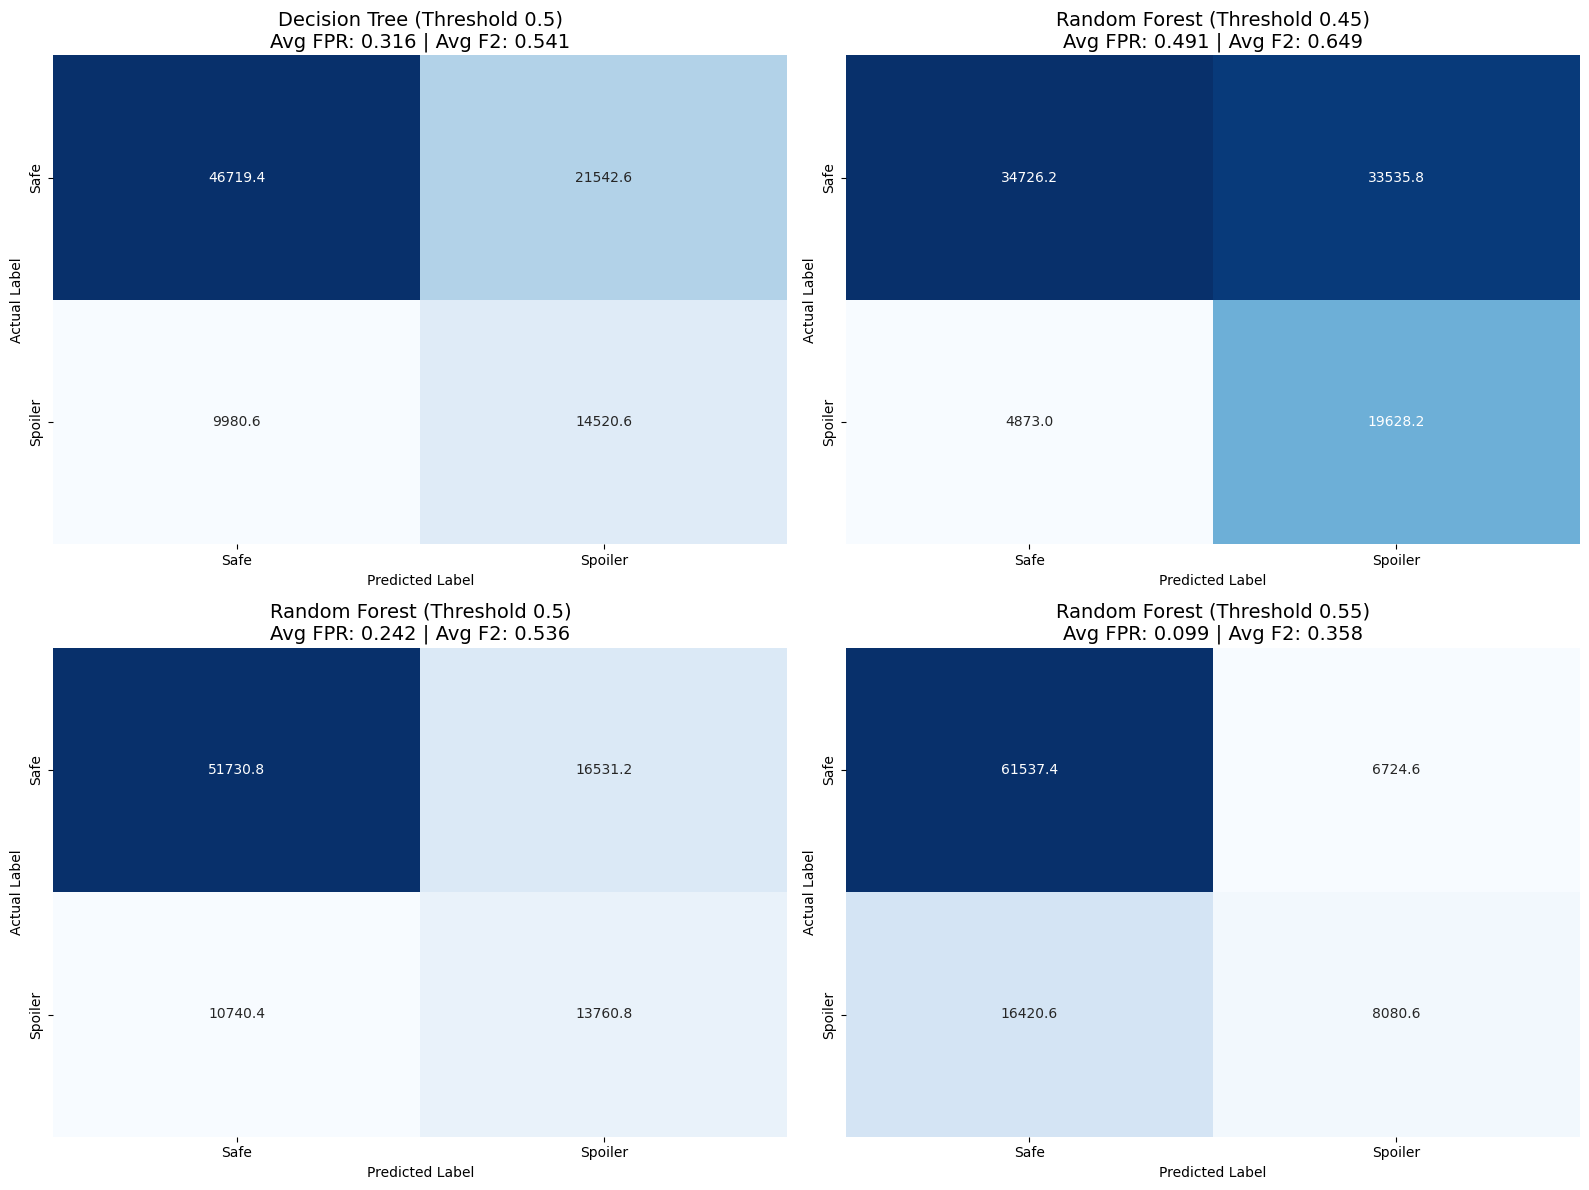

In [ ]:
from sklearn.metrics import confusion_matrix, recall_score, fbeta_score, accuracy_score

# 1. Configuration
N_SPLITS = 5  # Assuming 5-fold CV
threshold_dt = 0.5
thresholds_rf = [0.45, 0.5, 0.55]

# Using the best parameters identified previously
dt_params = {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001}
rf_params = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2}

# Containers for results
# We store the confusion matrices for every fold to calculate the "Average Matrix"
results = {
    "DT_0.5": {"cm": [], "fpr": [], "f2": []},
    "RF_0.45": {"cm": [], "fpr": [], "f2": []},
    "RF_0.5": {"cm": [], "fpr": [], "f2": []},
    "RF_0.55": {"cm": [], "fpr": [], "f2": []}
}

# 2. Cross-Validation Loop
for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="Calculating Average Metrics"):
    artifacts = load_cv_fold(fold_idx)
    X_train, y_train = artifacts["X_tfidf_train"], np.array(artifacts["y_train"]).ravel()
    X_val, y_val = artifacts["X_tfidf_val"], np.array(artifacts["y_val"]).ravel()

    # Train Models
    dt = DecisionTreeClassifier(**dt_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT).fit(X_train, y_train)
    rf = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1).fit(X_train, y_train)

    # Get Probabilities
    prob_dt = dt.predict_proba(X_val)[:, 1]
    prob_rf = rf.predict_proba(X_val)[:, 1]

    # Helper to store fold metrics
    def add_fold_data(key, y_true, y_prob, t):
        y_pred = (y_prob >= t)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        results[key]["cm"].append(cm)
        results[key]["fpr"].append(fp / (fp + tn))
        results[key]["f2"].append(fbeta_score(y_true, y_pred, beta=2, zero_division=0))

    add_fold_data("DT_0.5", y_val, prob_dt, threshold_dt)
    for t in thresholds_rf:
        add_fold_data(f"RF_{t}", y_val, prob_rf, t)

# 3. Plotting the 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_configs = [
    ("Decision Tree", "DT_0.5", 0.5),
    ("Random Forest", "RF_0.45", 0.45),
    ("Random Forest", "RF_0.5", 0.5),
    ("Random Forest", "RF_0.55", 0.55)
]

for i, (title, key, t) in enumerate(plot_configs):
    # Calculate Average Matrix and Average Metrics
    avg_cm = np.mean(results[key]["cm"], axis=0)
    avg_fpr = np.mean(results[key]["fpr"])
    avg_f2 = np.mean(results[key]["f2"])
    
    # Plotting
    sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{title} (Threshold {t})\nAvg FPR: {avg_fpr:.3f} | Avg F2: {avg_f2:.3f}", fontsize=14)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xticklabels(['Safe', 'Spoiler'])
    axes[i].set_yticklabels(['Safe', 'Spoiler'])

plt.tight_layout()
plt.show()

##### SAVE RESULTS

In [ ]:
# Save the best average metrics to CSV 
# Baseline - TF-IDF (Decision Tree)
best_cv_summary_dt_lemma.to_csv("dt_tfidf_lemma_best_summary.csv", index=False)

#### 4.6.2 TF-IDF + Lemmatization

##### Baseline Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

if USE_FIXED_BEST_PARAMS and DT_TFIDF_LEMMA_FIXED_PARAMS is not None:
    best_params_dt_lemma = normalize_dt_params(DT_TFIDF_LEMMA_FIXED_PARAMS)
    fold_rows = []
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="DT TF-IDF+Lemma fixed params"):
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        model = DecisionTreeClassifier(
            max_depth=best_params_dt_lemma["max_depth"],
            min_samples_split=best_params_dt_lemma["min_samples_split"],
            min_samples_leaf=best_params_dt_lemma["min_samples_leaf"],
            ccp_alpha=best_params_dt_lemma["ccp_alpha"],
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_dt_lemma = pd.DataFrame(fold_rows)
    fixed_cv_summary_dt_lemma = fixed_cv_fold_details_dt_lemma[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed params: {best_params_dt_lemma} (full search skipped)")
    print("Fold-by-fold metrics for fixed params:")
    display(fixed_cv_fold_details_dt_lemma.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed params:")
    display(fixed_cv_summary_dt_lemma.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_dt_lemma = []
    cv_fold_details_by_params_dt_lemma = {}

    sampled_param_grid = list(
        ParameterSampler(
            DT_PARAM_GRID,
            n_iter=min(DT_RANDOM_SEARCH_ITER, np.prod([len(v) for v in DT_PARAM_GRID.values()])),
            random_state=RANDOM_STATE,
        )
    )

    print(f"Evaluating {len(sampled_param_grid)} sampled parameter settings instead of the full grid.")

    for params in tqdm(sampled_param_grid, desc="DT TF-IDF+Lemma random search"):
        fold_rows = []
        for fold_idx in tqdm(
            range(1, N_SPLITS + 1),
            desc=f"CV folds {params}",
            leave=False,
        ):
            artifacts = load_cv_fold(fold_idx)
            X_train = artifacts["X_tfidf_lemma_train"]
            X_val = artifacts["X_tfidf_lemma_val"]
            y_train = artifacts["y_train"]
            y_val = artifacts["y_val"]
            model = DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_split=params["min_samples_split"],
                min_samples_leaf=params["min_samples_leaf"],
                ccp_alpha=params["ccp_alpha"],
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        params_key = tuple(params[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"])
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_params_dt_lemma[params_key] = fold_df
        cv_summary_rows_dt_lemma.append({
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "ccp_alpha": params["ccp_alpha"],
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_dt_lemma = pd.DataFrame(cv_summary_rows_dt_lemma).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across sampled hyperparameters (ranked by mean AUC):")
    display(cv_results_dt_lemma.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_dt_lemma = normalize_dt_params(cv_results_dt_lemma.loc[0, ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]])
    print(f"\nBest params by CV mean AUC: {best_params_dt_lemma}")
    print("Fold-by-fold metrics for best params:")
    display(cv_fold_details_by_params_dt_lemma[tuple(best_params_dt_lemma[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_dt_lemma = cv_fold_details_by_params_dt_lemma[tuple(best_params_dt_lemma[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best params:")
    display(best_cv_summary_dt_lemma.rename(columns={"average_precision": "pr-auc"}))

artifacts = load_full_train_test()
X_train_full = artifacts["X_tfidf_lemma_train_full"]
y_train_full = artifacts["y_train_full"]
final_model_dt_lemma = DecisionTreeClassifier(
    max_depth=best_params_dt_lemma["max_depth"],
    min_samples_split=best_params_dt_lemma["min_samples_split"],
    min_samples_leaf=best_params_dt_lemma["min_samples_leaf"],
    ccp_alpha=best_params_dt_lemma["ccp_alpha"],
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
 )
final_model_dt_lemma.fit(X_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
dt_tfidf_lemma_best_params = dict(best_params_dt_lemma)
dt_tfidf_lemma_model = final_model_dt_lemma

DT TF-IDF+Lemma fixed params: 100%|██████████| 5/5 [11:46<00:00, 141.35s/it]

Using fixed params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001} (full search skipped)
Fold-by-fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.693137,0.469110,0.482066,0.539222,0.409690,0.585502,0.667280,1
1,0.692629,0.466138,0.480106,0.529973,0.415020,0.569402,0.673549,2
2,0.691755,0.467873,0.479004,0.547379,0.396464,0.604947,0.651789,3
3,0.690898,0.466132,0.480843,0.550798,0.396841,0.609958,0.652777,4
4,0.689450,0.463070,0.473479,0.514350,0.418106,0.545757,0.680509,5


Average fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.691574,0.466465,0.4791,0.536345,0.407224,0.583113,0.665181


##### Decision Tree with Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, 
    fbeta_score, precision_score, recall_score, accuracy_score
)

# --- 0. CONFIGURATION ---
RF_THRESHOLD = 0.5

def normalize_rf_params(params_like):
    RF_INT_PARAMS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]
    params = dict(params_like)
    for name in RF_INT_PARAMS:
        if name in params:
            value = params.get(name)
            params[name] = None if value is None or pd.isna(value) else int(value)
    return params

# --- 1. CROSS-VALIDATION LOGIC ---

if USE_FIXED_BEST_PARAMS and globals().get('RF_TF_IDF_LEMMA_FIXED_PARAMS') is not None:
    best_params_rf = normalize_rf_params(RF_TF_IDF_LEMMA_FIXED_PARAMS)
    fold_rows = []
    
    for fold_idx in tqdm(range(1, N_SPLITS + 1), desc="RF Lemma fixed params"):
        # Load Lemma-specific artifacts
        artifacts = load_cv_fold(fold_idx)
        X_train = artifacts["X_tfidf_lemma_train"]
        X_val = artifacts["X_tfidf_lemma_val"]
        y_train = artifacts["y_train"]
        y_val = artifacts["y_val"]
        
        # Initialize and Train on full fold data
        model = RandomForestClassifier(
            **best_params_rf,
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1
        )
        model.fit(X_train, np.array(y_train).ravel())
        
        # Predict
        y_val_prob = model.predict_proba(X_val)[:, 1]
        
        # Calculate Metrics
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)
        
        # Cleanup memory immediately
        del artifacts, model, X_train, X_val
        gc.collect()

    # --- 2. OUTPUT DISPLAY ---
    fixed_cv_fold_details_rf = pd.DataFrame(fold_rows)
    fixed_cv_summary_rf = fixed_cv_fold_details_rf[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    
    print(f"Using fixed params: {best_params_rf} (full search skipped)")
    display(fixed_cv_fold_details_rf.rename(columns={"average_precision": "pr-auc"}))
    display(fixed_cv_summary_rf.rename(columns={"average_precision": "pr-auc"}))

else:
    # --- 3. RANDOM SEARCH LOGIC ---
    RF_PARAM_GRID = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    RF_RANDOM_SEARCH_ITER = 5
    
    cv_summary_rows_rf = []
    sampled_param_grid = list(ParameterSampler(RF_PARAM_GRID, n_iter=RF_RANDOM_SEARCH_ITER, random_state=RANDOM_STATE))

    for params in tqdm(sampled_param_grid, desc="RF Lemma random search"):
        fold_rows = []
        for fold_idx in range(1, N_SPLITS + 1):
            artifacts = load_cv_fold(fold_idx)
            X_train, y_train = artifacts["X_tfidf_lemma_train"], artifacts["y_train"]
            X_val, y_val = artifacts["X_tfidf_lemma_val"], artifacts["y_val"]
            
            model = RandomForestClassifier(**params, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
            model.fit(X_train, np.array(y_train).ravel())
            y_val_prob = model.predict_proba(X_val)[:, 1]
            
            fold_rows.append({
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= RF_THRESHOLD, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= RF_THRESHOLD, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= RF_THRESHOLD),
                "fold": fold_idx,
            })
            del artifacts, model
            gc.collect()
        
        fold_df = pd.DataFrame(fold_rows)
        cv_summary_rows_rf.append({
            **params,
            "mean_auc": fold_df["auc"].mean(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_rf = pd.DataFrame(cv_summary_rows_rf).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary (ranked by mean AUC):")
    display(cv_results_rf.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_rf = normalize_rf_params(cv_results_rf.loc[0, ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]])

# --- 4. FINAL MODEL TRAINING ON FULL DATA ---
artifacts_full = load_full_train_test()
X_train_full = artifacts_full["X_tfidf_lemma_train_full"]
y_train_full = np.array(artifacts_full["y_train_full"]).ravel()

final_model_rf_lemma = RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE, class_weight=CLASS_WEIGHT, n_jobs=-1)
final_model_rf_lemma.fit(X_train_full, y_train_full)

rf_tfidf_lemma_model = final_model_rf_lemma

RF Lemma fixed params: 100%|██████████| 5/5 [01:59<00:00, 23.88s/it]

Using fixed params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2} (full search skipped)


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.726444,0.495232,0.500594,0.537418,0.449286,0.565133,0.701804,1
1,0.731054,0.500450,0.501801,0.533952,0.456035,0.557778,0.706808,2
2,0.729109,0.499612,0.501197,0.538416,0.449419,0.566459,0.701655,3
3,0.725759,0.491308,0.496521,0.531396,0.447565,0.557501,0.701940,4
4,0.725463,0.498169,0.497373,0.527728,0.453862,0.550111,0.707343,5


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.727566,0.496954,0.499497,0.533782,0.451233,0.559396,0.70391


#### 4.6.3 BERT Embeddings

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterSampler

artifacts = load_full_train_test()
X_bert_train_full = artifacts["X_bert_train_full"]
y_train_full = artifacts["y_train_full"]

if USE_FIXED_BEST_PARAMS and DT_BERT_FIXED_PARAMS is not None:
    best_params_dt_bert = normalize_dt_params(DT_BERT_FIXED_PARAMS)
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in tqdm(
        enumerate(cv_splits, 1),
        total=len(cv_splits),
        desc="DT BERT fixed params",
    ):
        X_train = X_bert_train_full[train_idx]
        X_val = X_bert_train_full[val_idx]
        y_train = y_train_full[train_idx]
        y_val = y_train_full[val_idx]
        model = DecisionTreeClassifier(
            max_depth=best_params_dt_bert["max_depth"],
            min_samples_split=best_params_dt_bert["min_samples_split"],
            min_samples_leaf=best_params_dt_bert["min_samples_leaf"],
            ccp_alpha=best_params_dt_bert["ccp_alpha"],
            random_state=RANDOM_STATE,
            class_weight=CLASS_WEIGHT,
        )
        model.fit(X_train, y_train)
        y_val_prob = model.predict_proba(X_val)[:, 1]
        metrics = {
            "auc": roc_auc_score(y_val, y_val_prob),
            "average_precision": average_precision_score(y_val, y_val_prob),
            "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
            "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
            "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
            "fold": fold_idx,
        }
        fold_rows.append(metrics)

    fixed_cv_fold_details_dt_bert = pd.DataFrame(fold_rows)
    fixed_cv_summary_dt_bert = fixed_cv_fold_details_dt_bert[["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print(f"Using fixed params: {best_params_dt_bert} (full search skipped)")
    print("Fold-by-fold metrics for fixed params:")
    display(fixed_cv_fold_details_dt_bert.rename(columns={"average_precision": "pr-auc"}))
    print("Average fold metrics for fixed params:")
    display(fixed_cv_summary_dt_bert.rename(columns={"average_precision": "pr-auc"}))
else:
    cv_summary_rows_dt_bert = []
    cv_fold_details_by_params_dt_bert = {}

    sampled_param_grid = list(
        ParameterSampler(
            DT_PARAM_GRID,
            n_iter=min(DT_RANDOM_SEARCH_ITER, np.prod([len(v) for v in DT_PARAM_GRID.values()])),
            random_state=RANDOM_STATE,
        )
    )

    print(f"Evaluating {len(sampled_param_grid)} sampled parameter settings instead of the full grid.")

    for params in tqdm(sampled_param_grid, desc="DT BERT random search"):
        fold_rows = []
        for fold_idx, (train_idx, val_idx) in tqdm(
            enumerate(cv_splits, 1),
            total=len(cv_splits),
            desc=f"CV folds {params}",
            leave=False,
        ):
            X_train = X_bert_train_full[train_idx]
            X_val = X_bert_train_full[val_idx]
            y_train = y_train_full[train_idx]
            y_val = y_train_full[val_idx]
            model = DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_split=params["min_samples_split"],
                min_samples_leaf=params["min_samples_leaf"],
                ccp_alpha=params["ccp_alpha"],
                random_state=RANDOM_STATE,
                class_weight=CLASS_WEIGHT,
            )
            model.fit(X_train, y_train)
            y_val_prob = model.predict_proba(X_val)[:, 1]
            metrics = {
                "auc": roc_auc_score(y_val, y_val_prob),
                "average_precision": average_precision_score(y_val, y_val_prob),
                "f1": f1_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "f2": fbeta_score(y_val, y_val_prob >= 0.5, beta=2, zero_division=0),
                "precision": precision_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "recall": recall_score(y_val, y_val_prob >= 0.5, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_prob >= 0.5),
                "fold": fold_idx,
            }
            fold_rows.append(metrics)
        params_key = tuple(params[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"])
        fold_df = pd.DataFrame(fold_rows)
        cv_fold_details_by_params_dt_bert[params_key] = fold_df
        cv_summary_rows_dt_bert.append({
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "ccp_alpha": params["ccp_alpha"],
            "mean_auc": fold_df["auc"].mean(),
            "std_auc": fold_df["auc"].std(),
            "mean_average_precision": fold_df["average_precision"].mean(),
            "mean_f1": fold_df["f1"].mean(),
            "mean_f2": fold_df["f2"].mean(),
            "mean_precision": fold_df["precision"].mean(),
            "mean_recall": fold_df["recall"].mean(),
            "mean_accuracy": fold_df["accuracy"].mean(),
        })

    cv_results_dt_bert = pd.DataFrame(cv_summary_rows_dt_bert).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    print("CV summary across sampled hyperparameters (ranked by mean AUC):")
    display(cv_results_dt_bert.rename(columns={"mean_average_precision": "mean_pr-auc"}))
    best_params_dt_bert = normalize_dt_params(cv_results_dt_bert.loc[0, ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"]])
    print(f"\nBest params by CV mean AUC: {best_params_dt_bert}")
    print("Fold-by-fold metrics for best params:")
    display(cv_fold_details_by_params_dt_bert[tuple(best_params_dt_bert[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )].rename(columns={"average_precision": "pr-auc"}))
    best_cv_summary_dt_bert = cv_fold_details_by_params_dt_bert[tuple(best_params_dt_bert[name] for name in ["max_depth", "min_samples_split", "min_samples_leaf", "ccp_alpha"] )][["auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].mean().to_frame().T
    print("Average fold metrics for best params:")
    display(best_cv_summary_dt_bert.rename(columns={"average_precision": "pr-auc"}))

final_model_dt_bert = DecisionTreeClassifier(
    max_depth=best_params_dt_bert["max_depth"],
    min_samples_split=best_params_dt_bert["min_samples_split"],
    min_samples_leaf=best_params_dt_bert["min_samples_leaf"],
    ccp_alpha=best_params_dt_bert["ccp_alpha"],
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
 )
final_model_dt_bert.fit(X_bert_train_full, y_train_full)

# Keep model and selected hyperparameter available for model evaluation (section 6)
dt_bert_best_params = dict(best_params_dt_bert)
dt_bert_model = final_model_dt_bert

DT BERT fixed params: 100%|██████████| 5/5 [18:42<00:00, 224.52s/it]

Using fixed params: {'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'ccp_alpha': 0.0001} (full search skipped)
Fold-by-fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy,fold
0,0.631568,0.364841,0.441579,0.539721,0.338878,0.633599,0.576210,1
1,0.633489,0.367524,0.438484,0.518528,0.348756,0.590375,0.599727,2
2,0.629942,0.363498,0.441036,0.536761,0.339982,0.627568,0.579078,3
3,0.630867,0.366757,0.438073,0.530595,0.339427,0.617546,0.582346,4
4,0.626262,0.358022,0.427889,0.499869,0.345073,0.563008,0.603715,5


Average fold metrics for fixed params:


,auc,pr-auc,f1,f2,precision,recall,accuracy
0,0.630426,0.364129,0.437412,0.525094,0.342424,0.606419,0.588215


## 5. Final Test Set Evaluation

This section reports held-out test performance after hyperparameter tuning and final refitting are complete. Results are compared across the three feature representations: TF-IDF, TF-IDF + lemmatization, and BERT embeddings.

### 5.1 Logistic Regression

In [30]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

artifacts = load_full_train_test()

# TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_tfidf = logreg_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_tfidf = compute_metrics(y_test, y_test_prob_tfidf)

# TF-IDF + Lemma
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test_prob_lemma = logreg_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_lemma = compute_metrics(y_test, y_test_prob_lemma)

# BERT
X_test_bert = artifacts["X_bert_test"]
y_test_prob_bert = logreg_bert_model.predict_proba(X_test_bert)[:, 1]
test_metrics_bert = compute_metrics(y_test, y_test_prob_bert)

# Compare test results
test_metrics_df = pd.DataFrame([
    {"feature": "TF-IDF", **test_metrics_tfidf},
    {"feature": "TF-IDF+Lemma", **test_metrics_lemma},
    {"feature": "BERT", **test_metrics_bert}
])
print("\nFinal held-out test metrics (Logistic Regression):")
display(test_metrics_df[["feature", "auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].rename(columns={"average_precision": "PR-AUC"}))


Final held-out test metrics (Logistic Regression):


,feature,auc,PR-AUC,f1,f2,precision,recall,accuracy
0,TF-IDF,0.769532,0.560100,0.547740,0.604820,0.473294,0.649977,0.722884
1,TF-IDF+Lemma,0.768896,0.560012,0.544281,0.600265,0.471058,0.644457,0.721376
2,BERT,0.726816,0.472893,0.505442,0.591854,0.406521,0.667988,0.662507


### 5.2 Support Vector Machine

In [31]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

artifacts = load_full_train_test()

# TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_svm_tfidf = svm_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_svm_tfidf = compute_metrics(y_test, y_test_prob_svm_tfidf)

# TF-IDF + Lemma
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test_prob_svm_lemma = svm_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_svm_lemma = compute_metrics(y_test, y_test_prob_svm_lemma)

# BERT
X_test_bert = artifacts["X_bert_test"]
y_test_prob_svm_bert = svm_bert_model.predict_proba(X_test_bert)[:, 1]
test_metrics_svm_bert = compute_metrics(y_test, y_test_prob_svm_bert)

# Combine results
test_metrics_svm_df = pd.DataFrame([
    {"feature": "TF-IDF", **test_metrics_svm_tfidf},
    {"feature": "TF-IDF+Lemma", **test_metrics_svm_lemma},
    {"feature": "BERT", **test_metrics_svm_bert}
])
print("\nFinal held-out test metrics (SVM):")
display(test_metrics_svm_df[["feature", "auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].rename(columns={"average_precision": "PR-AUC"}))


Final held-out test metrics (SVM):


,feature,auc,PR-AUC,f1,f2,precision,recall,accuracy
0,TF-IDF,0.769424,0.557290,0.395962,0.317939,0.669985,0.281023,0.778638
1,TF-IDF+Lemma,0.768827,0.557438,0.392963,0.315019,0.668736,0.278228,0.778071
2,BERT,0.727076,0.472891,0.287482,0.220422,0.583189,0.190758,0.755872


### 5.3 Decision Tree

In [29]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

artifacts = load_full_train_test()

# TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_dt_tfidf = dt_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_dt_tfidf = compute_metrics(y_test, y_test_prob_dt_tfidf)

# Random Forest - TF-IDF
X_test_tfidf = artifacts["X_tfidf_test"]
y_test = artifacts["y_test"]
y_test_prob_rf_tfidf = rf_tfidf_model.predict_proba(X_test_tfidf)[:, 1]
test_metrics_rf_tfidf = compute_metrics(y_test, y_test_prob_rf_tfidf)

# TF-IDF + Lemmatization
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test_prob_dt_tfidf_lemma = dt_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_dt_lemma = compute_metrics(y_test, y_test_prob_dt_tfidf_lemma)

# Random Forest - TF-IDF + Lemmatization
X_test_lemma = artifacts["X_tfidf_lemma_test"]
y_test = artifacts["y_test"]
y_test_prob_rf_lemma = rf_tfidf_lemma_model.predict_proba(X_test_lemma)[:, 1]
test_metrics_rf_lemma = compute_metrics(y_test, y_test_prob_rf_lemma)

# BERT
X_test_bert = artifacts["X_bert_test"]
y_test_prob_dt_bert = dt_bert_model.predict_proba(X_test_bert)[:, 1]
test_metrics_dt_bert = compute_metrics(y_test, y_test_prob_dt_bert)

# Combine results
test_metrics_dt_df = pd.DataFrame([
    {"feature": "TF-IDF", **test_metrics_dt_tfidf},
    {"feature": "Random Forest - TF-IDF", **test_metrics_rf_tfidf},
    {"feature": "TF-IDF+Lemma", **test_metrics_dt_lemma},
    {"feature": "Random Forest - TF-IDF+Lemma", **test_metrics_rf_lemma},
    {"feature": "BERT", **test_metrics_dt_bert}
])
print("\nFinal held-out test metrics (Decision Tree):")
display(test_metrics_dt_df[["feature", "auc", "average_precision", "f1", "f2", "precision", "recall", "accuracy"]].rename(columns={"average_precision": "PR-AUC"}))


Final held-out test metrics (Decision Tree):


,feature,auc,PR-AUC,f1,f2,precision,recall,accuracy
0,TF-IDF,0.692569,0.462524,0.478271,0.546710,0.395709,0.604366,0.659574
1,Random Forest - TF-IDF,0.715887,0.462550,0.487602,0.535495,0.424349,0.573016,0.689073
2,TF-IDF+Lemma,0.695331,0.465628,0.474816,0.530535,0.404084,0.575563,0.671277
3,Random Forest - TF-IDF+Lemma,0.736428,0.501191,0.505452,0.548910,0.446531,0.582287,0.705818
4,BERT,0.631015,0.353597,0.431237,0.512974,0.340746,0.587170,0.600121
